In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Add, Activation

2025-12-14 20:49:14.782109: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 20:49:15.282781: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 20:49:18.162640: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
df = pd.read_csv('data/CICIDS2017.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [4]:
#loại bỏ dấu cách
df.columns = df.columns.str.strip()
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [5]:
selected_features = ['Bwd Packet Length Std', 'Average Packet Size', 'Flow Duration', 'Flow IAT Std']
X = df[selected_features].values
y = df['Label'].apply(lambda x: 1 if x == 'DDoS' else 0).values # 1: DDoS, 0: Benign

Model: "Ensemble_CNN_Framework"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn1_input          │ (None, 1, 4, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_input          │ (None, 1, 4, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_conv1_128      │ (None, 1, 4, 128) │        384 │ cnn1_input[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_conv1_128      │ (None, 1, 4, 128) │        384 │ cnn2_input[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_conv2_64       │ (None, 1, 4, 64)  │     16,448 │ cnn1_conv1_128[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_conv2_64       │ (None, 1, 4, 64)  │     16,448 │ cnn2_conv1_128[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_pool1          │ (None, 1, 2, 64)  │          0 │ cnn1_conv2_64[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_pool1          │ (None, 1, 2, 64)  │          0 │ cnn2_conv2_64[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_conv3_32       │ (None, 1, 2, 32)  │      4,128 │ cnn1_pool1[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_conv3_32       │ (None, 1, 2, 32)  │      4,128 │ cnn2_pool1[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_pool2          │ (None, 1, 1, 32)  │          0 │ cnn1_conv3_32[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_pool2          │ (None, 1, 1, 32)  │          0 │ cnn2_conv3_32[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_flatten        │ (None, 32)        │          0 │ cnn1_pool2[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_flatten        │ (None, 32)        │          0 │ cnn2_pool2[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_dense1 (Dense) │ (None, 64)        │      2,112 │ cnn1_flatten[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_dense1 (Dense) │ (None, 64)        │      2,112 │ cnn2_flatten[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1_dense2 (Dense) │ (None, 32)        │      2,080 │ cnn1_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn2_dense2 (Dense) │ (None, 32)        │      2,080 │ cnn2_dense1[0][0

 Total params: 50,337 (196.63 KB)

 Trainable params: 50,337 (196.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9593 - loss: 0.1143 - val_accuracy: 0.9722 - val_loss: 0.0818
Epoch 2/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9748 - loss: 0.0746 - val_accuracy: 0.9789 - val_loss: 0.0662
Epoch 3/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9763 - loss: 0.0682 - val_accuracy: 0.9803 - val_loss: 0.0659
Epoch 4/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9777 - loss: 0.0648 - val_accuracy: 0.9781 - val_loss: 0.0611
Epoch 5/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9779 - loss: 0.0635 - val_accuracy: 0.9803 - val_loss: 0.0565
Epoch 6/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9791 - loss: 0.0592 - val_accuracy: 0.9822 - val_loss: 0.0626
Epoch 7/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9810 - loss: 0.0541 - val_accuracy: 0.9823 - val_loss: 0.0513
Epoch 8/20
2822/2822 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9828 - loss: 0

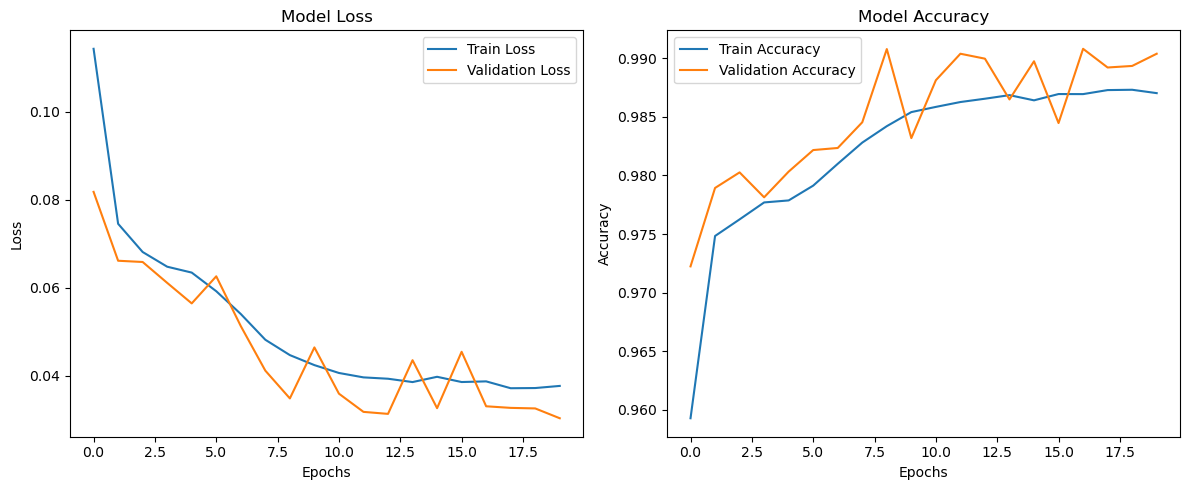

Model saved successfully!


In [8]:
# Chuyển đổi dữ liệu sang mảng numpy
X = df[selected_features].values
# Gán nhãn: 1 cho DDoS, 0 cho Benign (Bình thường)
y = df['Label'].apply(lambda x: 1 if x == 'DDoS' else 0).values 

# 2. SPLIT DATA [cite: 214]
# Chia tập dữ liệu: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Z-SCORE NORMALIZATION [cite: 234, 235]
# Chuẩn hóa dữ liệu (Mean=0, Std=1) để tăng hiệu quả huấn luyện Deep Learning
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lưu lại Scaler để sử dụng sau này trên SDN Controller
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 4. RESHAPE FOR CNN [cite: 245]
# CNN yêu cầu input 3 chiều (Height, Width, Depth). 
# Input gốc là (Batch, 4). Ta reshape thành (Batch, 1, 4, 1) tương ứng (Height=1, Width=4, Channel=1)
X_train_reshaped = X_train_scaled.reshape(-1, 1, 4, 1)
X_test_reshaped = X_test_scaled.reshape(-1, 1, 4, 1)

# 5. BUILD ENSEMBLE CNN MODEL ARCHITECTURE
def create_single_cnn(input_shape, prefix="cnn"):
    """
    Tạo một nhánh CNN đơn lẻ theo kiến trúc trong hình ảnh cung cấp[cite: 331, 332]:
    Conv(128) -> Conv(64) -> Pool -> Conv(32) -> Pool -> Flatten -> FC -> FC
    """
    inp = Input(shape=input_shape, name=f'{prefix}_input')
    
    # Layer 1: 2D-Conv, 128 Filters (Dựa trên hình ảnh layer dưới cùng)
    x = Conv2D(128, kernel_size=(1, 2), padding='same', activation='relu', name=f'{prefix}_conv1_128')(inp)
    
    # Layer 2: 2D-Conv, 64 Filters
    x = Conv2D(64, kernel_size=(1, 2), padding='same', activation='relu', name=f'{prefix}_conv2_64')(x)
    
    # Layer 3: MaxPooling 2D
    x = MaxPooling2D(pool_size=(1, 2), padding='same', name=f'{prefix}_pool1')(x)
    
    # Layer 4: 2D-Conv, 32 Filters
    x = Conv2D(32, kernel_size=(1, 2), padding='same', activation='relu', name=f'{prefix}_conv3_32')(x)
    
    # Layer 5: MaxPooling 2D
    x = MaxPooling2D(pool_size=(1, 2), padding='same', name=f'{prefix}_pool2')(x)
    
    # Layer 6: Flatten
    x = Flatten(name=f'{prefix}_flatten')(x)
    
    # Layer 7: 2 FC Layers (Fully Connected) [cite: 326]
    # Ta dùng 64 neurons cho lớp ẩn đầu tiên và 32 neurons cho lớp thứ hai
    x = Dense(64, activation='relu', name=f'{prefix}_dense1')(x)
    x = Dense(32, activation='relu', name=f'{prefix}_dense2')(x)
    
    # Trả về Model, output là feature vector (chưa qua Sigmoid) để chuẩn bị Merge
    return Model(inputs=inp, outputs=x, name=f'{prefix}_model')

input_shape = (1, 4, 1)

# Tạo 2 mô hình con giống hệt nhau cho Ensemble
cnn1 = create_single_cnn(input_shape, prefix="cnn1")
cnn2 = create_single_cnn(input_shape, prefix="cnn2")

# Merge 2 models (Ensemble) 
# Cộng vector đặc trưng của 2 model lại với nhau
merged = Add(name='ensemble_merge')([cnn1.output, cnn2.output])

# Layer cuối cùng: Sigmoid Classifier cho bài toán nhị phân (DDoS vs Benign) [cite: 327]
output = Dense(1, activation='sigmoid', name='output_sigmoid')(merged)

# Tạo mô hình tổng thể với 2 đầu vào và 1 đầu ra
ensemble_model = Model(inputs=[cnn1.input, cnn2.input], outputs=output, name='Ensemble_CNN_Framework')
ensemble_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# In tóm tắt mô hình để kiểm tra
ensemble_model.summary()

# 6. TRAIN & SAVE
# Huấn luyện mô hình với 2 đầu vào giống nhau (X_train_reshaped)
ensemble_model.fit(
    [X_train_reshaped, X_train_reshaped], 
    y_train, 
    epochs=20, 
    batch_size=64, 
    validation_data=([X_test_reshaped, X_test_reshaped], y_test)
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 7. Đánh giá mô hình trên tập Test
# Dự đoán xác suất
y_pred_prob = ensemble_model.predict([X_test_reshaped, X_test_reshaped])

# Chuyển xác suất sang nhãn 0 hoặc 1
y_pred = (y_pred_prob >= 0.5).astype(int).reshape(-1)

# Tính các chỉ số
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1-score : {f1:.6f}")

# Hoặc in báo cáo chi tiết
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'DDoS'], digits=6))
#VẼ biểu đồ hàm loss, accuracy trong quá trình huấn luyện
import matplotlib.pyplot as plt
history = ensemble_model.history
plt.figure(figsize=(12, 5))
# Vẽ đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Vẽ đồ thị Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
# Lưu mô hình đã huấn luyện
ensemble_model.save('ddos_ensemble_cnn.h5')
print("Model saved successfully!")